# 第一晚被刀玩家统计

从 `logs/session_*/game_complete.json` 与 `game_partial.json` 读取 `rounds[0].eliminated`（狼人刀的目标，**不论是否被医生救下**）。

若日志含 `name_to_display`（匿名模式），将真实姓名映射为 `play0` … `play7`，并绘制各位置被刀次数 / 频率柱状图。

In [4]:
from __future__ import annotations

import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt


def project_root() -> Path:
    cwd = Path.cwd()
    if (cwd / "logs").is_dir():
        return cwd
    if (cwd.parent / "logs").is_dir():
        return cwd.parent
    return cwd


LOGS = project_root() / "logs"

NUM_SLOTS = 8
PLAY_LABELS = [f"player{i}" for i in range(NUM_SLOTS)]


def load_name_to_display(data: dict) -> dict[str, str]:
    """真实名 -> player_k，如 Bert -> player_0"""
    for key in ("seer", "doctor"):
        p = data.get(key) or {}
        m = p.get("name_to_display") or {}
        if m:
            return dict(m)
    for v in data.get("villagers") or []:
        m = v.get("name_to_display") or {}
        if m:
            return dict(m)
    for w in data.get("werewolves") or []:
        m = w.get("name_to_display") or {}
        if m:
            return dict(m)
    return {}


def target_to_play_slot(target_name: str, name_to_display: dict[str, str]) -> str | None:
    """兼容两类日志：
    1) 旧格式: target 是真实名，需要 name_to_display 映射到 player_k
    2) 新格式: target 直接是 player_k 或 playk
    """
    if not target_name:
        return None

    # 新格式：target 已是 player_k / playk
    m_direct = re.search(r"(?:player_|play)(\d+)$", str(target_name))
    if m_direct:
        return f"player{int(m_direct.group(1))}"

    # 旧格式：通过 name_to_display 做真实名 -> player_k
    disp = name_to_display.get(target_name)
    if not disp:
        return None
    m_map = re.search(r"(?:player_|play)(\d+)$", str(disp))
    if not m_map:
        return None
    return f"player{int(m_map.group(1))}"


def first_night_kill_target(data: dict) -> str | None:
    rounds = data.get("rounds") or []
    if not rounds:
        return None
    return rounds[0].get("eliminated")


def iter_session_state_files(root: Path):
    """每个 session 目录只取一个状态文件：优先 game_complete.json。"""
    for d in sorted(root.glob("session_*")):
        if not d.is_dir():
            continue
        complete = d / "game_complete.json"
        partial = d / "game_partial.json"
        if complete.is_file():
            yield complete
        elif partial.is_file():
            yield partial


def collect_counts(logs_dir: Path) -> tuple[Counter[str], int, int]:
    """返回 (各 play 计数, 总局数含刀目标, 无法映射到 play 的局数)"""
    counts: Counter[str] = Counter()
    total_with_target = 0
    unmapped = 0

    for path in iter_session_state_files(logs_dir):
        try:
            data = json.loads(path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            continue

        target = first_night_kill_target(data)
        if target is None:
            continue

        total_with_target += 1
        ntd = load_name_to_display(data)
        slot = target_to_play_slot(str(target), ntd)
        if slot is None:
            unmapped += 1
            continue
        counts[slot] += 1

    return counts, total_with_target, unmapped


In [5]:
counts, n_games, n_unmapped = collect_counts(LOGS)

# 固定 8 个槽位，缺失为 0
values = [counts.get(f"player{i}", 0) for i in range(NUM_SLOTS)]
mapped = n_games - n_unmapped
probs = [v / mapped if mapped else 0.0 for v in values]

print(f"logs 目录: {LOGS.resolve()}")
print(f"有第一晚刀目标的局数: {n_games}")
print(f"可映射到 player0–player7 的局数: {mapped}")
print(f"无法映射（无 name_to_display 等）: {n_unmapped}")
print("各位置被刀次数:", dict(zip(PLAY_LABELS, values)))

logs 目录: D:\Github_Clone\werewolf_arena\logs
有第一晚刀目标的局数: 4
可映射到 play0–play7 的局数: 4
无法映射（无 name_to_display 等）: 0
各位置被刀次数: {'play0': 2, 'play1': 1, 'play2': 1, 'play3': 0, 'play4': 0, 'play5': 0, 'play6': 0, 'play7': 0}


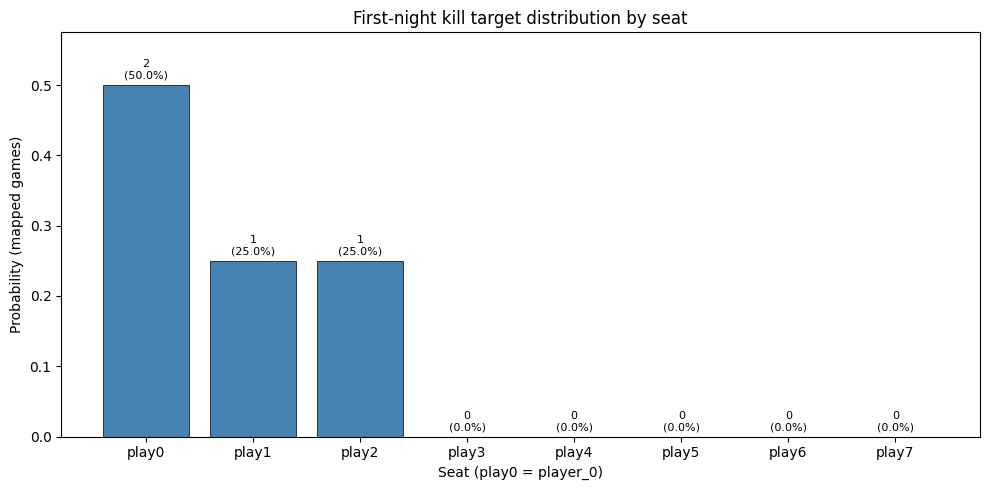

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(NUM_SLOTS)
bars = ax.bar(x, probs, color="steelblue", edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(PLAY_LABELS)
ax.set_ylabel("Probability (mapped games)")
ax.set_xlabel("Player")
ax.set_title("First-night kill target distribution by seat")
ax.set_ylim(0, max(probs) * 1.15 if max(probs) > 0 else 1.0)

for i, bar in enumerate(bars):
    h = bar.get_height()
    ax.annotate(
        f"{values[i]}\n({100 * probs[i]:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, h),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()